# 02 – Feature Engineering Visualization

This notebook visualizes the **featured dataset** (`data/featured_data.csv`) produced by `src/preprocessing/feature_engineering.py`.

We inspect the 9 new engineered features and how they relate to the target variable `tr_status`.


## 1. Load Featured Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)

df = pd.read_csv('../data/featured_data.csv', nrows=250_000, low_memory=False)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nNew engineered features:')
new_feats = ['hour_of_day','day_of_week','is_weekend','total_code_churn',
             'test_to_src_ratio','total_files_changed','is_large_commit',
             'test_fail_ratio','project_failure_rate']
print(new_feats)


Shape: 250,000 rows x 56 columns

New engineered features:
['hour_of_day', 'day_of_week', 'is_weekend', 'total_code_churn', 'test_to_src_ratio', 'total_files_changed', 'is_large_commit', 'test_fail_ratio', 'project_failure_rate']


In [2]:
df[new_feats].describe().T


,count,mean,std,min,25%,50%,75%,max
hour_of_day,250000.0,12.887888,6.835781,0.0,8.000000,14.000000,19.000000,23.0
day_of_week,250000.0,2.714224,1.889343,0.0,1.000000,3.000000,4.000000,6.0
total_code_churn,250000.0,1.255464,18.452757,0.0,0.000000,0.000000,0.000000,3398.0
test_to_src_ratio,250000.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
total_files_changed,250000.0,5.649344,38.250359,0.0,1.000000,2.000000,4.000000,8022.0
test_fail_ratio,250000.0,0.010076,0.077429,0.0,0.000000,0.000000,0.000000,1.0
project_failure_rate,250000.0,0.353176,0.214852,0.0,0.202778,0.300748,0.481166,1.0


## 2. Time-Based Features

Do builds fail more at certain hours or on weekends?


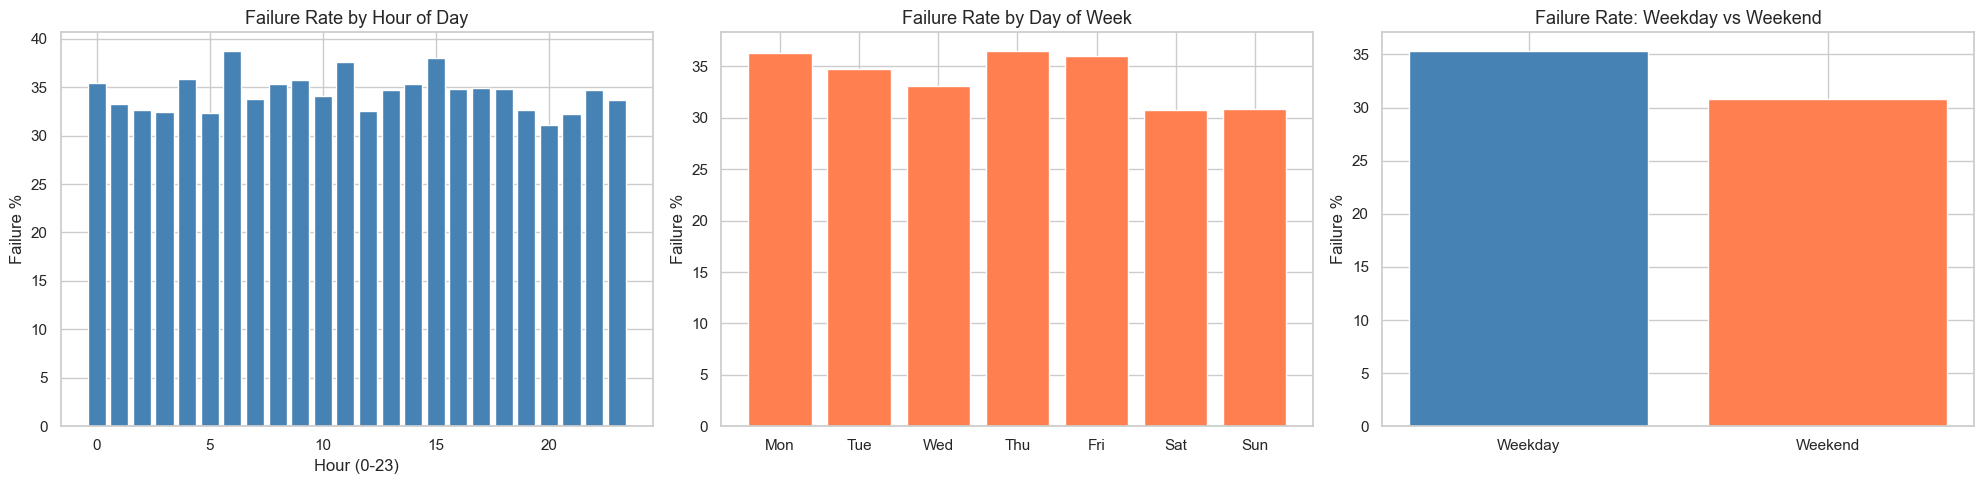

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Hour of day
hour_fail = df.groupby('hour_of_day')['tr_status'].apply(
    lambda x: (x.isin(['failed','errored'])).mean() * 100
)
axes[0].bar(hour_fail.index, hour_fail.values, color='steelblue')
axes[0].set_title('Failure Rate by Hour of Day', fontsize=13)
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Failure %')

# Day of week
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_fail = df.groupby('day_of_week')['tr_status'].apply(
    lambda x: (x.isin(['failed','errored'])).mean() * 100
)
axes[1].bar(day_fail.index, day_fail.values, color='coral')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].set_title('Failure Rate by Day of Week', fontsize=13)
axes[1].set_ylabel('Failure %')

# Weekend vs weekday
wk_fail = df.groupby('is_weekend')['tr_status'].apply(
    lambda x: (x.isin(['failed','errored'])).mean() * 100
)
axes[2].bar(['Weekday','Weekend'], wk_fail.values, color=['steelblue','coral'])
axes[2].set_title('Failure Rate: Weekday vs Weekend', fontsize=13)
axes[2].set_ylabel('Failure %')

plt.tight_layout()
plt.show()


## 3. Commit-Based Features

How do code churn, file changes, and commit size relate to failure?


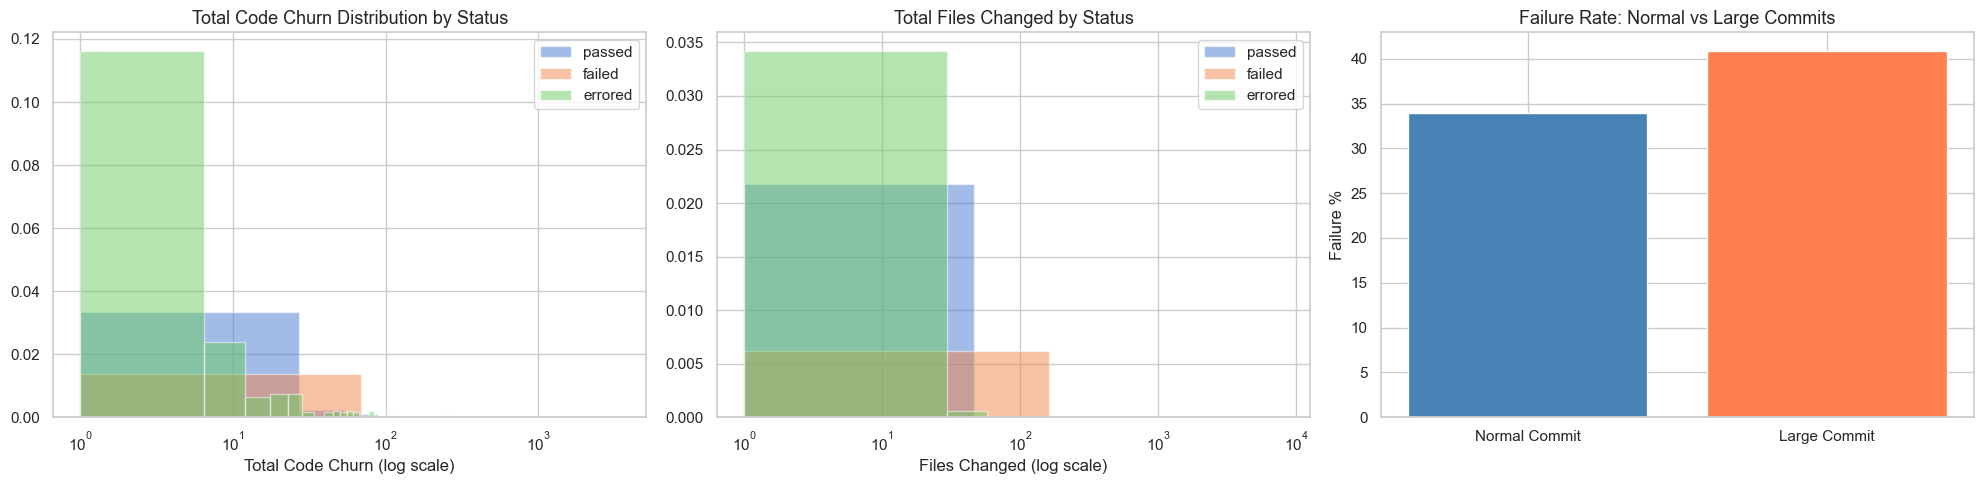

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Total code churn distribution
for status in ['passed','failed','errored']:
    subset = df[df['tr_status'] == status]['total_code_churn']
    subset = subset[subset > 0]  # skip zeros for log scale
    if len(subset) > 0:
        axes[0].hist(subset, bins=50, alpha=0.5, label=status, density=True)
axes[0].set_xscale('log')
axes[0].set_title('Total Code Churn Distribution by Status', fontsize=13)
axes[0].set_xlabel('Total Code Churn (log scale)')
axes[0].legend()

# Total files changed
for status in ['passed','failed','errored']:
    subset = df[df['tr_status'] == status]['total_files_changed']
    subset = subset[subset > 0]
    if len(subset) > 0:
        axes[1].hist(subset, bins=50, alpha=0.5, label=status, density=True)
axes[1].set_xscale('log')
axes[1].set_title('Total Files Changed by Status', fontsize=13)
axes[1].set_xlabel('Files Changed (log scale)')
axes[1].legend()

# is_large_commit vs failure
large_fail = df.groupby('is_large_commit')['tr_status'].apply(
    lambda x: (x.isin(['failed','errored'])).mean() * 100
)
axes[2].bar(['Normal Commit','Large Commit'], large_fail.values,
            color=['steelblue','coral'])
axes[2].set_title('Failure Rate: Normal vs Large Commits', fontsize=13)
axes[2].set_ylabel('Failure %')

plt.tight_layout()
plt.show()


## 4. Test Features

How does `test_fail_ratio` distribute across build statuses?


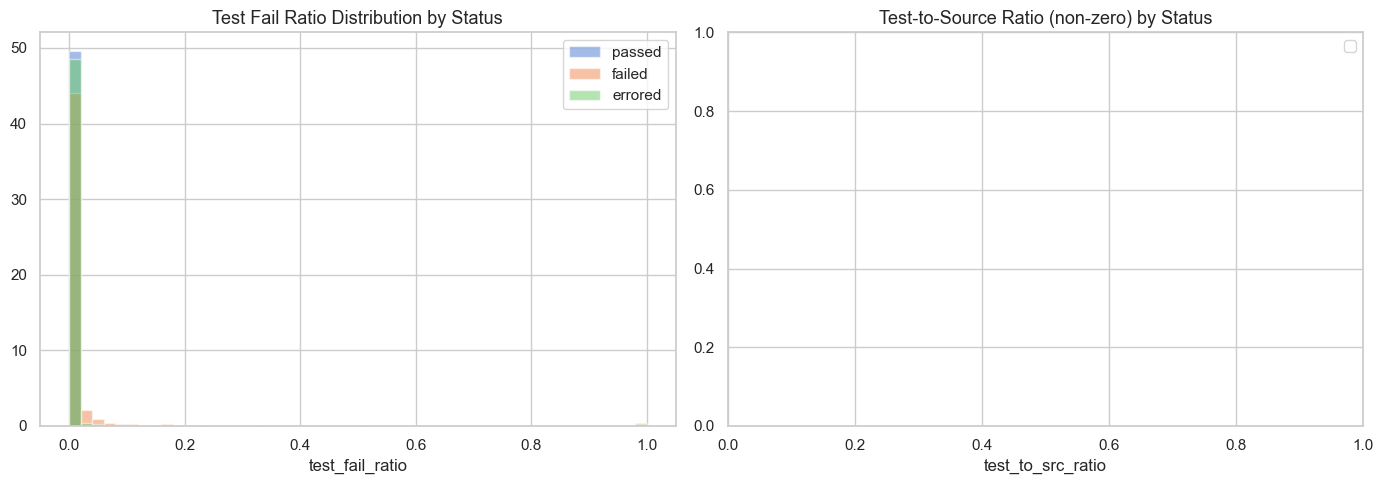

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# test_fail_ratio distribution
for status in ['passed','failed','errored']:
    subset = df[df['tr_status'] == status]['test_fail_ratio']
    axes[0].hist(subset, bins=50, alpha=0.5, label=status, density=True)
axes[0].set_title('Test Fail Ratio Distribution by Status', fontsize=13)
axes[0].set_xlabel('test_fail_ratio')
axes[0].legend()

# test_to_src_ratio
for status in ['passed','failed','errored']:
    subset = df[df['tr_status'] == status]['test_to_src_ratio']
    subset = subset[subset > 0]
    if len(subset) > 0:
        axes[1].hist(subset, bins=50, alpha=0.5, label=status, density=True)
axes[1].set_title('Test-to-Source Ratio (non-zero) by Status', fontsize=13)
axes[1].set_xlabel('test_to_src_ratio')
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Project Failure Rate

Historical rolling failure rate per project — does a project's past predict its future?


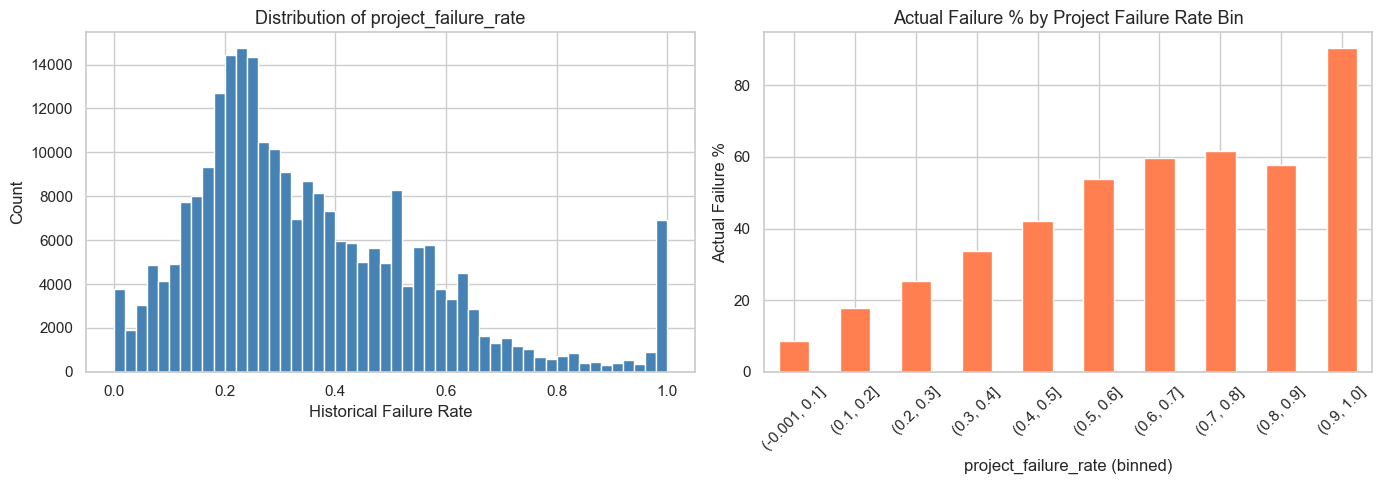

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['project_failure_rate'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of project_failure_rate', fontsize=13)
axes[0].set_xlabel('Historical Failure Rate')
axes[0].set_ylabel('Count')

# Failure rate vs actual status
df['_is_fail'] = df['tr_status'].isin(['failed','errored']).astype(int)
bins = pd.cut(df['project_failure_rate'], bins=10)
fail_by_bin = df.groupby(bins)['_is_fail'].mean() * 100
fail_by_bin.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Actual Failure % by Project Failure Rate Bin', fontsize=13)
axes[1].set_xlabel('project_failure_rate (binned)')
axes[1].set_ylabel('Actual Failure %')
axes[1].tick_params(axis='x', rotation=45)
df.drop(columns=['_is_fail'], inplace=True)

plt.tight_layout()
plt.show()


## 6. Correlation of Engineered Features


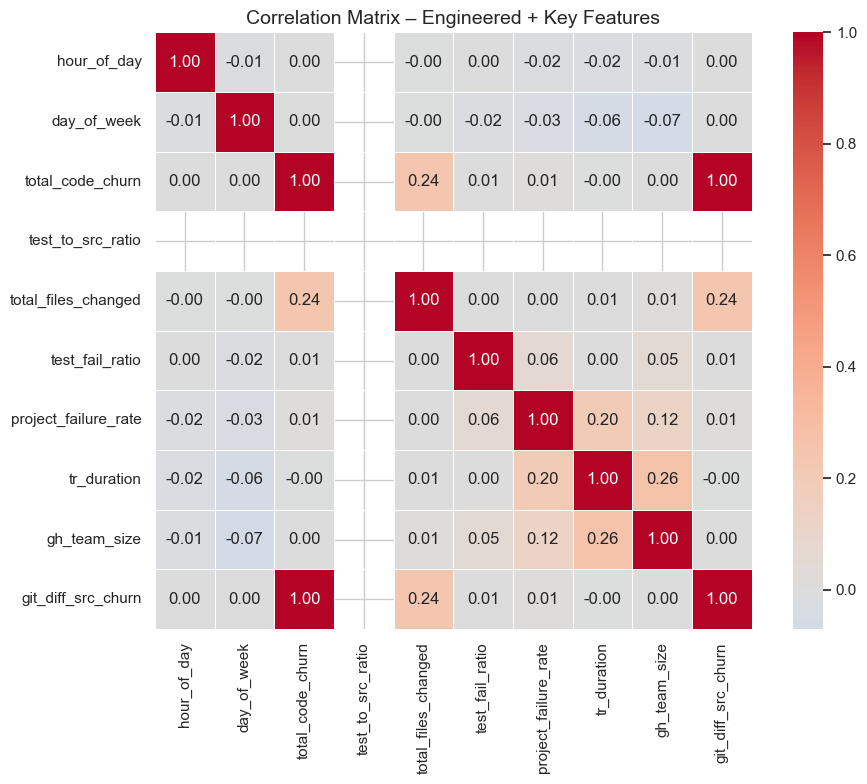

In [7]:
feat_cols = ['hour_of_day','day_of_week','total_code_churn',
             'test_to_src_ratio','total_files_changed',
             'test_fail_ratio','project_failure_rate',
             'tr_duration','gh_team_size','git_diff_src_churn']
feat_cols = [c for c in feat_cols if c in df.columns]

corr = df[feat_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix – Engineered + Key Features', fontsize=14)
plt.tight_layout()
plt.show()


## 7. Summary

| Feature | Insight |
|---------|--------|
| `hour_of_day` | Failure rates may vary by hour — useful for time-aware predictions |
| `day_of_week` / `is_weekend` | Weekend builds may have different failure patterns |
| `total_code_churn` | Larger changes → higher risk of breakage |
| `total_files_changed` | More files touched → more chances for conflicts |
| `is_large_commit` | Binary flag for high-risk commits |
| `test_to_src_ratio` | Low ratio may indicate insufficient test coverage |
| `test_fail_ratio` | Directly correlated with build failure |
| `project_failure_rate` | Projects with history of failures tend to fail again |

**Next step:** `src/preprocessing/encode.py` - encode target, language, and boolean columns.
